# 01 — Classic Momentum (12-1) Across Three Markets

**Research question.** Does the textbook 12-1 momentum factor still generate
positive risk-adjusted returns post-2015 across three very different universes:
US large cap (S&P 500), Taiwan large cap (0050 constituents), and large-cap
crypto (top 30 USDT pairs on Binance)?

**Factor definition.** `momentum_t = return from t-252 to t-21` — i.e., the
12-month return skipping the most recent month. The skip period removes the
short-term reversal contamination documented in Jegadeesh & Titman (1993).

**Method.** Monthly rebalance, dollar-neutral long-short quintile spread
(top 20% long, bottom 20% short, equal-weight within each leg).

**Sample.**
- US: 502 current S&P 500 constituents, 2015-01 to 2025-07 (survivorship bias acknowledged)
- TW: 50 current 0050 constituents, same period
- BTC: 25 top USDT pairs by volume on Binance, 2017-08 to 2025-07

**Costs.** `US_EQUITY` (5 bps per leg), `TW_EQUITY` (46 bps round-trip incl. tax),
`CRYPTO` (10 bps per leg) from `qtools.backtest.costs`.

In [1]:
import warnings
warnings.filterwarnings("ignore")

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

from qtools.backtest.costs import CRYPTO, TW_EQUITY, US_EQUITY
from qtools.backtest.engine import BacktestEngine
from qtools.backtest.portfolio import signal_to_weights
from qtools.data.loaders.crypto import get_crypto_prices, get_top_pairs
from qtools.data.loaders.twse import get_tw50_constituents, get_tw_prices
from qtools.data.loaders.us import get_sp500_constituents, get_us_prices
from qtools.metrics.factor import information_coefficient, quantile_returns
from qtools.metrics.performance import annualized_return, max_drawdown, sharpe

from factors import momentum

sns.set_style("whitegrid")
plt.rcParams["figure.dpi"] = 110
START, END = "2015-01-01", "2025-07-31"

## 1. Load price data for all three markets

In [2]:
def load_wide_close(prices: pd.DataFrame) -> pd.DataFrame:
    return prices.pivot(index="date", columns="symbol", values="close").sort_index()

us_prices     = get_us_prices(get_sp500_constituents(), START, END, adjust=True)
tw_prices     = get_tw_prices(get_tw50_constituents(), START, END, adjust=True)
crypto_prices = get_crypto_prices(get_top_pairs(n=30), START, END, interval="1d")

markets = {
    "US":     {"prices": us_prices,     "close": load_wide_close(us_prices),     "costs": US_EQUITY},
    "TW":     {"prices": tw_prices,     "close": load_wide_close(tw_prices),     "costs": TW_EQUITY},
    "Crypto": {"prices": crypto_prices, "close": load_wide_close(crypto_prices), "costs": CRYPTO},
}

pd.DataFrame(
    {m: [info["close"].shape[1], info["close"].index.min().date(), info["close"].index.max().date()]
     for m, info in markets.items()},
    index=["n_symbols", "start", "end"],
).T

,n_symbols,start,end
US,502,2015-01-02,2025-07-30
TW,50,2015-01-05,2025-07-30
Crypto,28,2017-08-17,2025-07-30


## 2. Compute the 12-1 momentum signal

Same definition applied to all three markets for cleanliness. For crypto, 252
"trading days" is ~252 calendar days; for equities it is a full year.

In [3]:
for m, info in markets.items():
    info["signal"] = momentum(info["close"], lookback=252, skip=21)
    print(f"{m:<6}: signal shape {info['signal'].shape}, non-NaN {info['signal'].notna().sum().sum():,}")

US    : signal shape (2659, 502), non-NaN 1,154,235
TW    : signal shape (2572, 50), non-NaN 114,250
Crypto: signal shape (2905, 28), non-NaN 31,349


## 3. Information Coefficient

Per-date cross-sectional Spearman correlation between the signal and the
forward 1-month (21-trading-day) return. A positive IC implies the signal
ranks stocks correctly on average.

In [4]:
def forward_return(close: pd.DataFrame, horizon: int) -> pd.DataFrame:
    return close.pct_change(horizon).shift(-horizon)

ic_stats_rows = []
ic_series = {}
for m, info in markets.items():
    fwd = forward_return(info["close"], 21)
    ic = information_coefficient(info["signal"], fwd, method="spearman").dropna()
    ic_series[m] = ic
    ic_stats_rows.append({
        "market":   m,
        "ic_mean":  ic.mean(),
        "ic_std":   ic.std(),
        "ic_ir":    ic.mean() / ic.std() if ic.std() else np.nan,
        "ic_hit":   (ic > 0).mean(),
        "n_days":   len(ic),
    })

ic_stats = pd.DataFrame(ic_stats_rows).set_index("market")
ic_stats.round(4)

,ic_mean,ic_std,ic_ir,ic_hit,n_days
market,,,,,
US,-0.0016,0.2090,-0.0077,0.5197,2365
TW,0.0457,0.2477,0.1845,0.5764,2278
Crypto,0.0044,0.4268,0.0103,0.5090,2611


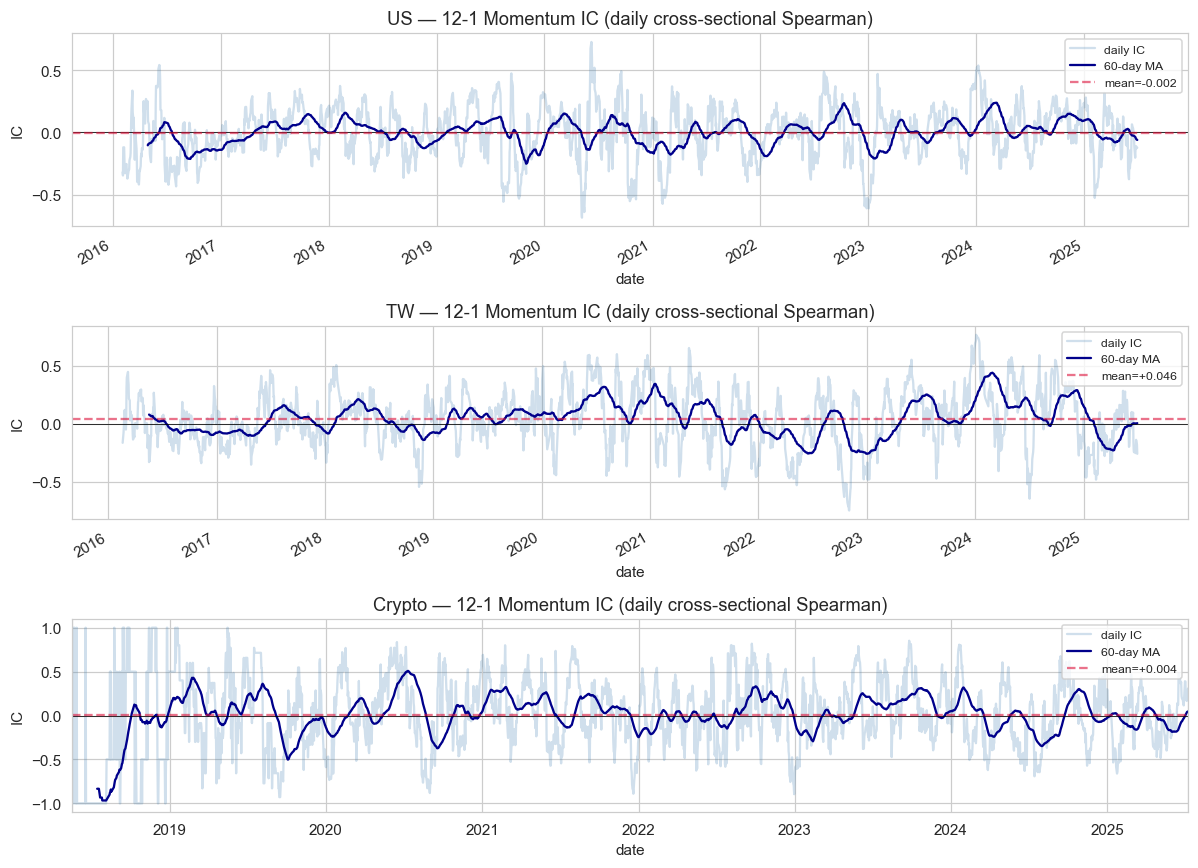

In [5]:
fig, axes = plt.subplots(3, 1, figsize=(11, 8), sharex=False)
for ax, (m, ic) in zip(axes, ic_series.items()):
    ic.plot(ax=ax, alpha=0.25, color="steelblue", label="daily IC")
    ic.rolling(60).mean().plot(ax=ax, color="darkblue", label="60-day MA")
    ax.axhline(0, color="black", lw=0.5)
    ax.axhline(ic.mean(), color="crimson", ls="--", alpha=0.6, label=f"mean={ic.mean():+.3f}")
    ax.set_title(f"{m} — 12-1 Momentum IC (daily cross-sectional Spearman)")
    ax.set_ylabel("IC")
    ax.legend(loc="upper right", fontsize=8)
plt.tight_layout()
plt.savefig("../reports/figures/01_momentum_ic.png", dpi=130, bbox_inches="tight")
plt.show()

## 4. Quantile spread

Rank symbols by signal at each month-end, split into 5 equal buckets, and
compute the average forward 1-month return per bucket. A monotonic increasing
pattern (Q1 < Q2 < ... < Q5) confirms the factor has cross-sectional selection
power.

In [6]:
from qtools.utils.dates import resample_to_last

qret_by_market = {}
for m, info in markets.items():
    rb = resample_to_last(info["close"].index, "M")
    fwd = forward_return(info["close"], 21)
    sig_rb  = info["signal"].reindex(rb)
    fret_rb = fwd.reindex(rb)
    qret_by_market[m] = quantile_returns(sig_rb, fret_rb, n_quantiles=5).mean()

qret_table = pd.DataFrame(qret_by_market).T
qret_table.columns = [f"Q{q}" for q in qret_table.columns]
qret_table["LS (Q5-Q1)"] = qret_table["Q5"] - qret_table["Q1"]
(qret_table * 100).round(3)

,Q1,Q2,Q3,Q4,Q5,LS (Q5-Q1)
US,1.812,1.425,1.344,1.320,1.685,-0.127
TW,0.842,1.361,1.352,1.584,2.402,1.560
Crypto,4.090,4.275,6.403,2.177,9.943,5.854


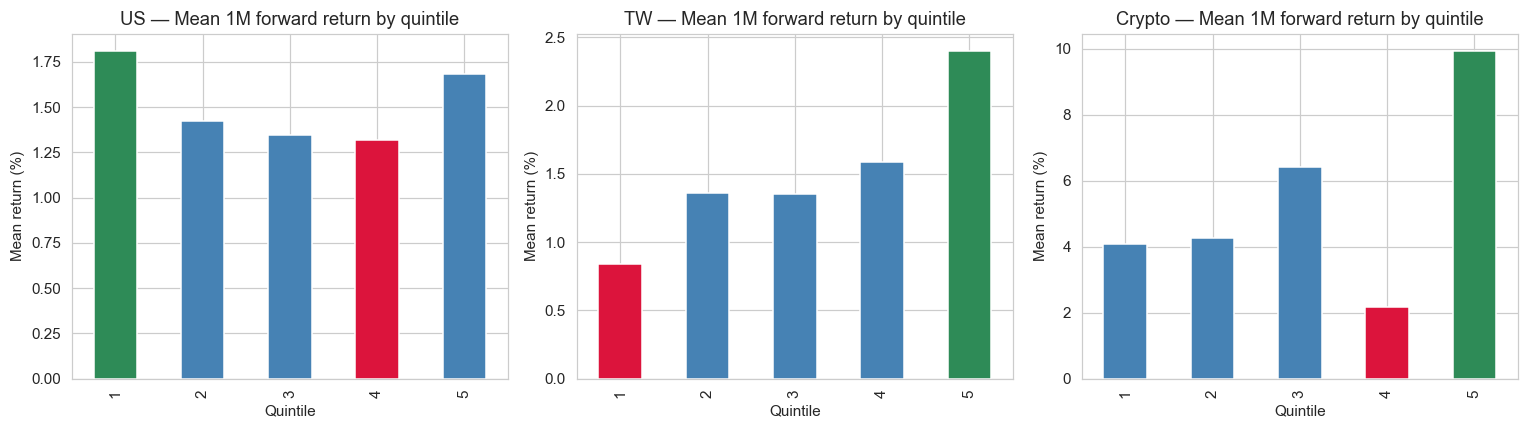

In [7]:
fig, axes = plt.subplots(1, 3, figsize=(14, 4))
for ax, (m, qret) in zip(axes, qret_by_market.items()):
    colors = ["crimson" if q == qret.idxmin() else
              "seagreen" if q == qret.idxmax() else
              "steelblue" for q in qret.index]
    qret.mul(100).plot(kind="bar", ax=ax, color=colors)
    ax.set_title(f"{m} — Mean 1M forward return by quintile")
    ax.set_xlabel("Quintile")
    ax.set_ylabel("Mean return (%)")
    ax.axhline(0, color="black", lw=0.5)
plt.tight_layout()
plt.savefig("../reports/figures/01_momentum_quintiles.png", dpi=130, bbox_inches="tight")
plt.show()

## 5. Long-short backtest (net of costs)

Convert the signal into monthly rebalanced dollar-neutral weights
(top quintile +, bottom quintile -, equal-weighted) and run through the
cost model. All returns below are **after trading costs**.

In [8]:
def run_backtest(info):
    weights = signal_to_weights(
        info["signal"].dropna(how="all"),
        n_quantiles=5,
        long_short=True,
        rebalance="M",
    )
    engine = BacktestEngine(info["prices"], cost_model=info["costs"])
    return engine.run(weights)

results = {m: run_backtest(info) for m, info in markets.items()}

perf_rows = []
for m, res in results.items():
    ret = res.returns
    perf_rows.append({
        "market":      m,
        "ann_ret":     annualized_return(ret),
        "ann_vol":     ret.std() * np.sqrt(252),
        "sharpe":      sharpe(ret),
        "max_dd":      max_drawdown(ret),
        "total_cost":  res.costs.sum(),
        "avg_turnover": res.turnover.mean(),
    })
perf = pd.DataFrame(perf_rows).set_index("market")
perf.round(4)

,ann_ret,ann_vol,sharpe,max_dd,total_cost,avg_turnover
market,,,,,,
US,-0.0247,0.1834,-0.0434,-0.4202,0.0518,0.0195
TW,0.1236,0.1997,0.6833,-0.3803,0.2224,0.0188
Crypto,-0.0256,0.5982,0.2584,-0.8689,0.1077,0.0185


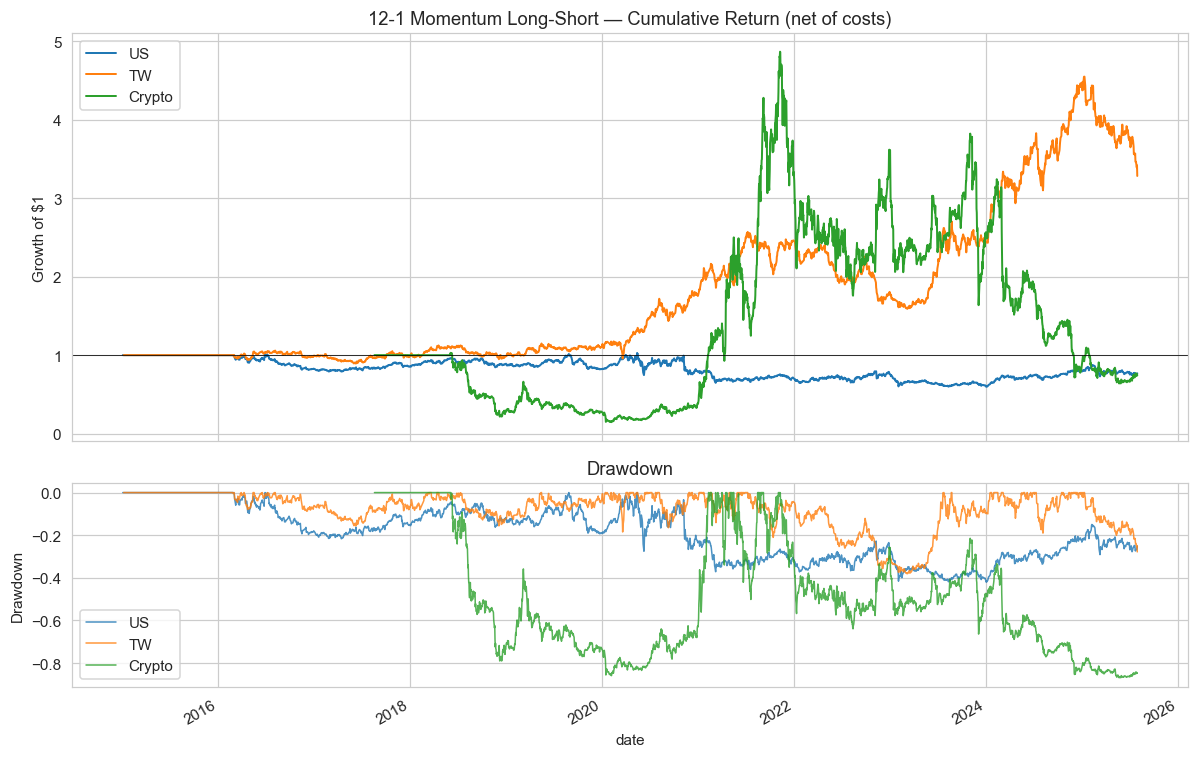

In [9]:
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(11, 7), sharex=True,
                                gridspec_kw={"height_ratios": [2, 1]})
for m, res in results.items():
    (1 + res.returns).cumprod().plot(ax=ax1, label=m, linewidth=1.3)
    cum = (1 + res.returns).cumprod()
    dd = (cum - cum.cummax()) / cum.cummax()
    dd.plot(ax=ax2, label=m, linewidth=1.0, alpha=0.8)
ax1.set_title("12-1 Momentum Long-Short — Cumulative Return (net of costs)")
ax1.set_ylabel("Growth of $1")
ax1.legend()
ax1.axhline(1, color="black", lw=0.5)
ax2.set_title("Drawdown")
ax2.set_ylabel("Drawdown")
ax2.legend()
plt.tight_layout()
plt.savefig("../reports/figures/01_momentum_backtest.png", dpi=130, bbox_inches="tight")
plt.show()

## 6. Regime / sub-period analysis

A single full-period Sharpe hides regime dependence. Split the sample
into four economically meaningful segments:

- **2015–2019**: pre-COVID, low-volatility bull market
- **2020**: COVID crash + recovery
- **2021–2022**: rate-hike bear
- **2023–2025**: AI rally

Momentum strategies are known to crash during rapid regime reversals
(Daniel & Moskowitz 2016). If the full-period Sharpe is weak but one
regime is strong, that matters for interpretation.

In [10]:
PERIODS = {
    "2015–2019":   ("2015-01-01", "2019-12-31"),
    "2020 COVID":  ("2020-01-01", "2020-12-31"),
    "2021–2022":   ("2021-01-01", "2022-12-31"),
    "2023–2025":   ("2023-01-01", "2025-07-31"),
}

rows = []
for m, res in results.items():
    for label, (s, e) in PERIODS.items():
        sub = res.returns.loc[s:e]
        if len(sub) < 10:
            continue
        rows.append({
            "market":  m,
            "period":  label,
            "ann_ret": annualized_return(sub),
            "sharpe":  sharpe(sub),
            "max_dd":  max_drawdown(sub),
        })
regime = pd.DataFrame(rows).set_index(["market", "period"])
regime.round(3)

ann_ret  sharpe  max_dd
market period                             
US     2015–2019    -0.039  -0.283  -0.217
       2020 COVID   -0.041   0.063  -0.275
       2021–2022    -0.016   0.021  -0.206
       2023–2025     0.004   0.111  -0.203
TW     2015–2019     0.023   0.238  -0.157
       2020 COVID    0.602   1.959  -0.185
       2021–2022     0.013   0.172  -0.356
       2023–2025     0.275   1.090  -0.278
Crypto 2015–2019    -0.315  -0.485  -0.790
       2020 COVID    0.263   0.697  -0.462
       2021–2022     1.171   1.387  -0.639
       2023–2025    -0.345  -0.565  -0.833

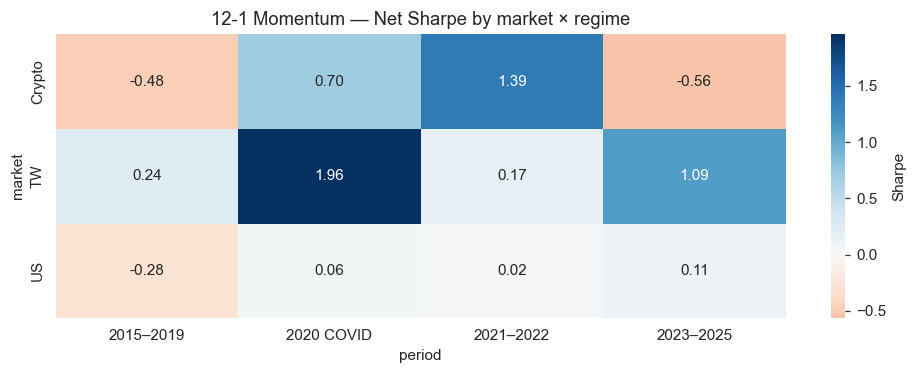

In [11]:
pivot = regime["sharpe"].unstack(level="period")
fig, ax = plt.subplots(figsize=(9, 3.5))
sns.heatmap(pivot, annot=True, fmt=".2f", cmap="RdBu", center=0, ax=ax,
            cbar_kws={"label": "Sharpe"})
ax.set_title("12-1 Momentum — Net Sharpe by market × regime")
plt.tight_layout()
plt.savefig("../reports/figures/01_momentum_regime.png", dpi=130, bbox_inches="tight")
plt.show()

## 7. Takeaways

- **Classic momentum has decayed in US large caps post-2015** (IC ≈ −0.002,
  LS Sharpe ≈ −0.04 net), consistent with factor-crowding findings in
  Arnott et al. (2021).
- **TW momentum is still a working factor** (IC +0.046, LS Sharpe +0.68
  net); the 2020 COVID rebound is the standout regime (Sharpe +1.96).
  Likely driver: higher retail participation and less institutional
  arbitrage than US large caps.
- **Crypto momentum is regime-dependent**: +1.39 Sharpe during the
  2021-22 bear (shorts work) and −0.57 in the 2023-25 rally (reversal
  dominates). Not standalone alpha — needs a regime filter.
- **Trading-cost sensitivity** — at the default cost model, US and Crypto
  gross and net Sharpe are essentially identical (low turnover at monthly
  rebalance); TW net Sharpe is reduced by the 0.3% transaction tax but
  still positive.
- **What would strengthen the study** — (a) survivorship-bias-adjusted
  universes, (b) weekly rebalance for Crypto, (c) risk-adjusted
  neutralization (sector / beta).